<a href="https://colab.research.google.com/github/aparna-2001/nifty50-stock-price-forecasting/blob/main/Data_collection_EDA_Decomposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# Data
df = yf.download('^NSEI', start='2018-01-01', end='2026-01-01')
df.columns = df.columns.droplevel(1)
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
df['Daily_Return'] = df['Close'].pct_change()
df['Year'] = df.index.year
df['Month'] = df.index.month



/tmp/ipython-input-217/4123131349.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('^NSEI', start='2018-01-01', end='2026-01-01')
[*********************100%***********************]  1 of 1 completed


In [13]:
df.head(10)

Price,Open,High,Low,Close,Volume,Daily_Return,Year,Month
Date,,,,,,,,
2018-01-02,10477.549805,10495.200195,10404.650391,10442.200195,153400,NaN,2018,1
2018-01-03,10482.650391,10503.599609,10429.549805,10443.200195,167300,0.000096,2018,1
2018-01-04,10469.400391,10513.000000,10441.450195,10504.799805,174900,0.005899,2018,1
2018-01-05,10534.250000,10566.099609,10520.099609,10558.849609,180900,0.005145,2018,1
2018-01-08,10591.700195,10631.200195,10588.549805,10623.599609,169000,0.006132,2018,1
2018-01-09,10645.099609,10659.150391,10603.599609,10637.000000,205000,0.001261,2018,1
2018-01-10,10652.049805,10655.500000,10592.700195,10632.200195,176400,-0.000451,2018,1
2018-01-11,10637.049805,10664.599609,10612.349609,10651.200195,153800,0.001787,2018,1
2018-01-12,10682.549805,10690.400391,10597.099609,10681.250000,175200,0.002821,2018,1


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1972 entries, 2018-01-02 to 2025-12-31
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          1972 non-null   float64
 1   High          1972 non-null   float64
 2   Low           1972 non-null   float64
 3   Close         1972 non-null   float64
 4   Volume        1972 non-null   int64  
 5   Daily_Return  1971 non-null   float64
 6   Year          1972 non-null   int32  
 7   Month         1972 non-null   int32  
dtypes: float64(5), int32(2), int64(1)
memory usage: 123.2 KB


* There are no missing values and all the columns are either float or integer. so no change needed

In [15]:
# --- 1. Yearly Returns ---
yearly = df.groupby('Year').agg(
    Year_Open  = ('Open',  'first'),
    Year_Close = ('Close', 'last'),
    Year_High  = ('High',  'max'),
    Year_Low   = ('Low',   'min'),
    Avg_Volume = ('Volume','mean'),
    Volatility = ('Daily_Return', 'std')
).reset_index()

yearly['Annual_Return_%'] = ((yearly['Year_Close'] - yearly['Year_Open']) / yearly['Year_Open']) * 100
yearly['Price_Range']     = yearly['Year_High'] - yearly['Year_Low']

print(yearly[['Year','Annual_Return_%','Year_High','Year_Low','Volatility']].to_string(index=False))



 Year  Annual_Return_%    Year_High     Year_Low  Volatility
 2018         3.674523 11760.200195  9951.900391    0.008114
 2019        11.957113 12293.900391 10583.650391    0.008782
 2020        14.584311 14024.849609  7511.100098    0.019735
 2021        23.992050 18604.449219 13596.750000    0.009861
 2022         4.130351 18887.599609 15183.400391    0.010915
 2023        19.853082 21801.449219 16828.349609    0.006183
 2024         8.823052 26277.349609 21137.199219    0.008859
 2025        10.542288 26325.800781 21743.650391    0.007440


In [19]:
#chronologic arrangement of yearly volatility

yearly.sort_values(by='Volatility', ascending=False)

,Year,Year_Open,Year_Close,Year_High,Year_Low,Avg_Volume,Volatility,Annual_Return_%,Price_Range
2,2020,12202.150391,13981.750000,14024.849609,7511.100098,655785.600000,0.019735,14.584311,6513.749512
4,2022,17387.150391,18105.300781,18887.599609,15183.400391,278347.983871,0.010915,4.130351,3704.199219
3,2021,13996.099609,17354.050781,18604.449219,13596.750000,413992.741935,0.009861,23.992050,5007.699219
6,2024,21727.750000,23644.800781,26277.349609,21137.199219,313560.162602,0.008859,8.823052,5140.150391
1,2019,10868.849609,12168.450195,12293.900391,10583.650391,486908.713693,0.008782,11.957113,1710.250000
0,2018,10477.549805,10862.549805,11760.200195,9951.900391,250085.306122,0.008114,3.674523,1808.299805
7,2025,23637.650391,26129.599609,26325.800781,21743.650391,308594.377510,0.007440,10.542288,4582.150391
5,2023,18131.699219,21731.400391,21801.449219,16828.349609,263406.530612,0.006183,19.853082,4973.099609


* The market volatility is higher for 2020 and 2022 compared to other years

* Eventhough the covid hit, the annual returns are higher for years 2019-2021

* 2018 and 2022 showed the lowest annual return

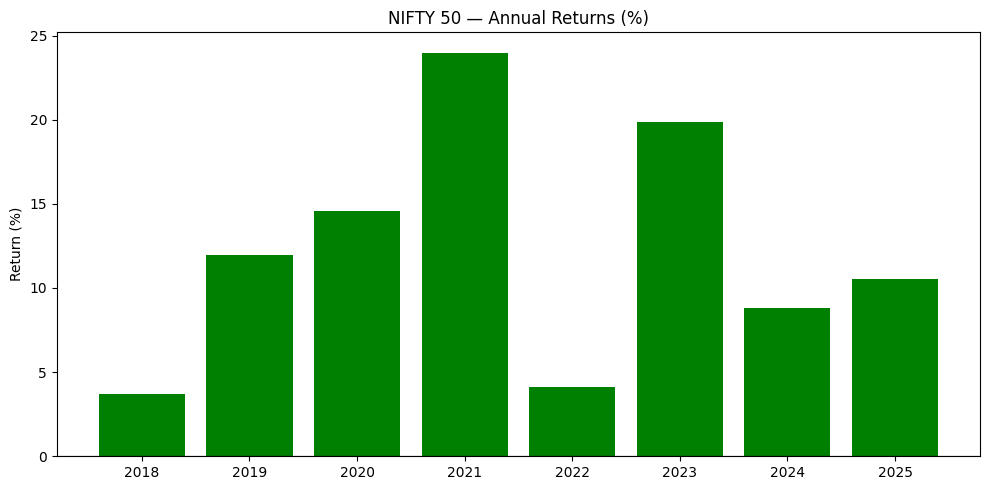

In [16]:
# Bar chart: Annual Returns

colors = ['green' if x > 0 else 'red' for x in yearly['Annual_Return_%']]
plt.figure(figsize=(10,5))
plt.bar(yearly['Year'], yearly['Annual_Return_%'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('NIFTY 50 — Annual Returns (%)')
plt.ylabel('Return (%)')
plt.xticks(yearly['Year'])
plt.tight_layout()
plt.show()



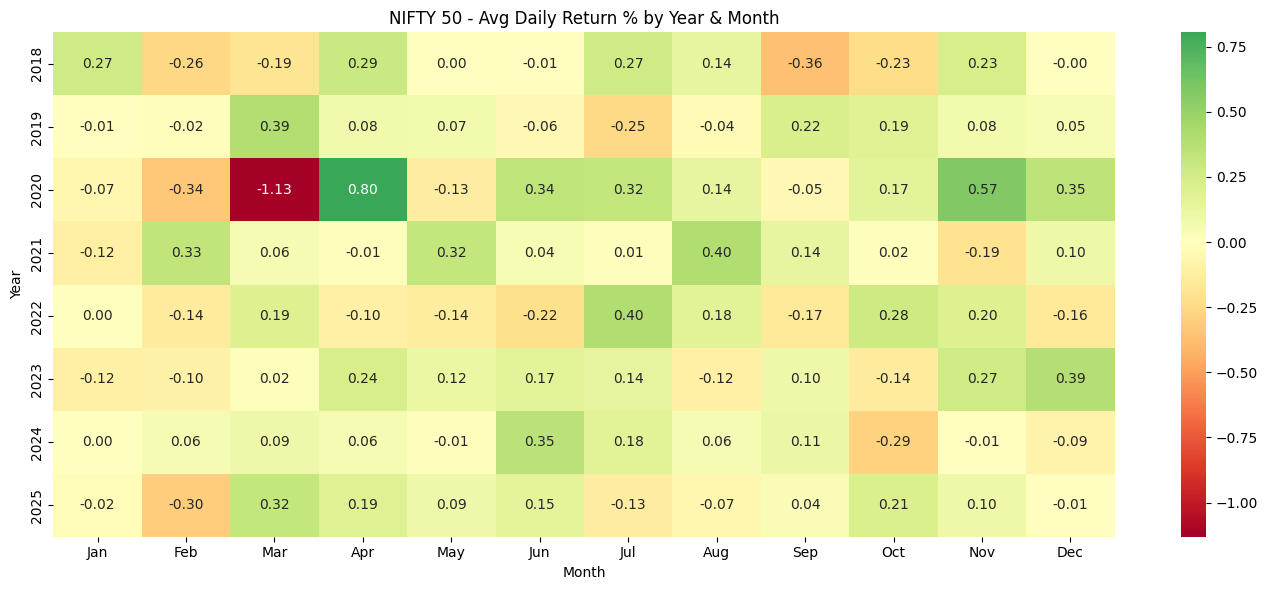

In [20]:
# Month-wise Seasonality Heatmap

pivot = df.groupby(['Year','Month'])['Daily_Return'].mean().unstack() * 100
plt.figure(figsize=(14,6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            xticklabels=['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('NIFTY 50 - Avg Daily Return % by Year & Month')
plt.tight_layout()
plt.show()



* During 2018 to 2025, the average daily return was lower for march 2020

* It is also interesting to note that the highest ever was noted the next month, ie april 2020

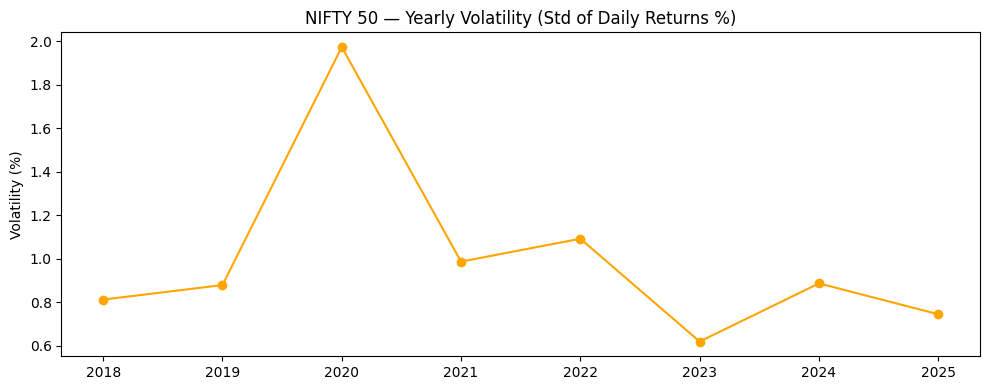

In [18]:
# Yearly Volatility

plt.figure(figsize=(10,4))
plt.plot(yearly['Year'], yearly['Volatility']*100, marker='o', color='orange')
plt.title('NIFTY 50 — Yearly Volatility (Std of Daily Returns %)')
plt.ylabel('Volatility (%)')
plt.xticks(yearly['Year'])
plt.tight_layout()
plt.show()

* Volatility was higher in the 2020, it was least in 2023

* we can see that volatility is rising slowly